# 💰 Build a Financial Intelligence RAG Assistant with LangGraph

## 📋 Project Overview

In this project, you will demonstrate advanced RAG (Retrieval-Augmented Generation) capabilities by building an end-to-end **Financial Intelligence Assistant** using **LangGraph** for workflow orchestration. You'll process a corpus of 30 financial guidance documents and create a production-ready system that answers personal finance questions with strict grounding and zero hallucination.

Personal finance is a **high-stakes domain** where incorrect or fabricated answers can cause real harm. You will implement architectural patterns that ensure every answer is traceable, verifiable, and grounded strictly in source documents.

---

## 🎯 Objectives

- **Document Indexing**: You will build a vector database with 30 financial guidance documents using ChromaDB
- **Multi-Strategy Retrieval**: You will implement both semantic search and hybrid search (BM25 + semantic) approaches
- **Grounded Generation**: You will create an LLM pipeline that refuses to answer when information is unavailable
- **Production Architecture**: You will use LangGraph for stateful, observable, and maintainable workflow orchestration

---

## 🏗️ Retrieval Strategies

### Strategy 1: Semantic Search (Vector Similarity)
**Approach**: You will use dense embeddings and cosine similarity for retrieval
**Advantage**: Captures semantic meaning and conceptual relationships
**Best For**: Paraphrased queries, conceptual questions, synonym matching

### Strategy 2: Hybrid Search (Semantic + BM25)
**Approach**: You will combine vector similarity with keyword-based BM25 retrieval using Reciprocal Rank Fusion
**Advantage**: Balances semantic understanding with exact term matching
**Best For**: Queries with specific financial terminology (401(k), Roth IRA, HSA, credit score)

---

## 🛠️ Technical Stack

- **LLM**: OpenAI GPT-4.1-mini (fast, cost-efficient, deterministic at temperature=0)
- **Embeddings**: OpenAI text-embedding-3-small (1536-dim vectors)
- **Vector Store**: ChromaDB with cosine similarity
- **Orchestration**: LangGraph StateGraph for stateful workflow management
- **Retrieval**: LangChain retrievers (semantic + BM25 ensemble)

---

## 📊 Pipeline Workflow

You will need to index documents into a Vector DB.

Then, you will build a LangGraph pipeline that flows through the following nodes:

1. **Retrieve Node**: You will fetch relevant documents using hybrid retrieval (semantic + BM25)
2. **Generate Node**: You will construct grounded prompts with source metadata and invoke the LLM
3. **State Management**: You will track questions, retrieved documents, answers, and source citations

This is the detailed architecture workflow:
![](https://i.imgur.com/3hzVQM7.png)

Simplified workflow diagram:

```
┌──────────┐    ┌──────────┐    ┌──────────────────────────────────────────┐
│  Step 1  │    │  Step 2  │    │               Step 3 — LangGraph         │
│          │    │          │    │                                          │
│   Load   │───►│  Embed   │───►│   START → retrieve_node → generate_node → END
│   text   │    │  + Store │    │                                          │
│   Docs   │    │ ChromaDB │    │   RAGState: {question, retrieved_docs,   │
│          │    │ + OpenAI │    │              answer, sources}            │
└──────────┘    └──────────┘    └──────────────────────────────────────────┘
     ▲               ▲
     │   Run once    │
     └───────────────┘
      persisted to disk
```

---

## 💡 Key Features

✅ **Strict Grounding**: You will enforce that every answer comes only from retrieved documents

✅ **Safe Refusal**: You will implement fallback behavior for out-of-scope or unanswerable queries

✅ **Source Attribution**: You will track and display which documents were used in each answer

✅ **Transparent Retrieval**: You will log document titles and metadata at each pipeline step

✅ **Production-Ready**: You will use LangGraph for modular, extensible, and testable workflows

---

## 🧪 Testing & Evaluation

You will validate your RAG system with real-world queries spanning:

1. **Direct Factual Questions**: "How much should I have in an emergency fund?"
   - Tests basic retrieval and single-document grounding

2. **Multi-Document Synthesis**: "You have no emergency fund, some credit card debt, and an average credit score. What steps should you take to budget, build savings, pay down debt, and improve your credit safely?"
   - Tests cross-document retrieval and coherent synthesis across multiple financial topics (budgeting, emergency funds, debt management, credit scores)

3. **Comparison Questions**: "What is the difference between a 401(k) and a Roth IRA?"
   - Tests ability to retrieve and compare information from multiple related documents

4. **Partial Information Handling**: "How does the debt snowball method work, and based on my exact debts and income, when will I be completely debt-free?"
   - Tests refusal behavior when only partial information is available (method explanation: yes, personalized timeline: no)

5. **Hallucination Tests**: "Exactly how much money will I need to retire at age 60, and what monthly investment amount guarantees I get there?"
   - Tests out-of-scope personalized calculation handling and safe refusal behavior

---

## 🎓 Learning Outcomes

By completing this project, you will understand:
- How to build production-ready RAG pipelines with LangGraph
- The tradeoffs between semantic and hybrid retrieval strategies
- Best practices for preventing hallucination in high-stakes domains
- Techniques for ensuring answer traceability and source attribution
- How to evaluate RAG system behavior with edge cases and refusal scenarios

---



---

## ⚙️ Environment Setup

### Installation

We install all required packages for this project.

| Package | Purpose |
|---|---|
| `langgraph` | Graph-based LLM orchestration framework |
| `langchain` | Core LangChain framework for chaining LLM components |
| `langchain-classic` | Advanced retrievers — `EnsembleRetriever` |
| `langchain-openai` | OpenAI LLM and embedding model integrations |
| `langchain-community` | Community retrievers including BM25 |
| `langchain-chroma` | ChromaDB vector store integration |
| `rank-bm25` | BM25 sparse retrieval algorithm |

In [ ]:
!pip install -q langchain==1.2.8
!pip install -q langchain-classic==1.0.1
!pip install -q langchain-openai==1.1.9
!pip install -q langchain-community==0.4.1
!pip install -q langgraph==1.0.7
!pip install -q rank-bm25==0.2.2
!pip install -q langchain-chroma==1.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

---

### 🔑 API Keys

We securely load the OpenAI API key using `getpass`, which prompts for input without displaying the key in notebook output or storing it in the cell.

> **Never hardcode API keys directly in your notebook.** Using `getpass` ensures keys stay out of version control and shared outputs.

You will need:
- **OpenAI API Key** — Use the one provided to you during the program OR get yours at [platform.openai.com/api-keys](https://platform.openai.com/api-keys)

In [ ]:
# get api key
import os
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")

In [ ]:
# import os
# from getpass import getpass

# # Set up OpenAI API key securely
# os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API Key: ")

---

### 🤖 LLM & Embedder Setup

We initialise two OpenAI models:

| Model | Parameter | Value | Reason |
|---|---|---|---|
| **Chat** | `model` | `gpt-4.1-mini` | Fast, cost-efficient model well-suited for RAG answer generation |
| **Chat** | `temperature` | `0` | Deterministic outputs — critical for grounded, factual financial guidance |
| **Embeddings** | `model` | `text-embedding-3-small` | 1536-dim vectors, strong semantic representation at low cost |

In [ ]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
)

embedder = OpenAIEmbeddings(
    model="text-embedding-3-small",
)

In [ ]:
# Quick connectivity test
llm.invoke("Explain AI in one sentence.").text

'Artificial Intelligence (AI) is the simulation of human intelligence processes by machines, especially computer systems, enabling them to perform tasks such as learning, reasoning, and problem-solving.'

---

### 📦 Download Dataset

We download the financial guidance documents from Google Drive. The zip contains **30 text files**, one per financial topic.

In [ ]:
!gdown 1fnSryQS2voh84_Ha05wMPCaA8veUECrA

Downloading...
From: https://drive.google.com/uc?id=1fnSryQS2voh84_Ha05wMPCaA8veUECrA
To: /content/capstone_financial_documents.zip
100% 19.9k/19.9k [00:00<00:00, 42.3MB/s]


In [ ]:
!unzip -q capstone_financial_documents.zip

In [ ]:
!ls -l ./capstone_financial_documents/ | head -10

total 120
-rw-rw-rw- 1 root root  830 Feb 19 06:58 doc_01_credit_scores.txt
-rw-rw-rw- 1 root root 1153 Feb 19 06:58 doc_02_retirement_planning.txt
-rw-rw-rw- 1 root root  841 Feb 19 06:58 doc_03_roth_ira.txt
-rw-rw-rw- 1 root root  824 Feb 19 06:58 doc_04_401k_plans.txt
-rw-rw-rw- 1 root root  717 Feb 19 06:58 doc_05_budgeting.txt
-rw-rw-rw- 1 root root  665 Feb 19 06:58 doc_06_emergency_funds.txt
-rw-rw-rw- 1 root root  709 Feb 19 06:58 doc_07_hsa_accounts.txt
-rw-rw-rw- 1 root root  717 Feb 19 06:58 doc_08_credit_card_rewards.txt
-rw-rw-rw- 1 root root  670 Feb 19 06:58 doc_09_interest_rates.txt


---

## 📄 Step 1 — Load Financial Documents

### Building a Text Document Loader with Metadata Enrichment

Each document is a structured text file with the following format:

```
Title: Understanding Credit Scores

A credit score is a numerical representation...
```

### Why No Chunking?

Unlike long-form documents where a single page may cover many unrelated topics, each financial guidance document is already a **tightly scoped, single-topic document**. It covers exactly one financial concept. Splitting it further would:

- Break the natural flow of financial information  
- Reduce retrieval quality by embedding partial context instead of the full picture
- Create artificial chunk boundaries where none are meaningful

We embed the **full text** while preserving the title for metadata.

---

### 📋 Metadata Strategy

Every `Document` object is enriched with metadata extracted from the file:

| Metadata Field | Source | Example |
|---|---|---|
| `title` | First line of text file | `Understanding Credit Scores` |
| `filename` | File stem | `doc_01_credit_scores` |
| `source` | Full file path | `./capstone_financial_documents/doc_01_credit_scores.txt` |

This metadata travels with every document through retrieval and into the LLM prompt, enabling the model to cite specific sources in its answers.

In [ ]:
# Let's examine a sample document
sample_file = "./capstone_financial_documents/doc_01_credit_scores.txt"
with open(sample_file, "r", encoding="utf-8") as f:
    sample_content = f.read()

print(sample_content)

Title: Understanding Credit Scores

A credit score is a numerical representation of your creditworthiness, typically ranging from 300 to 850. It’s used by lenders, landlords, and sometimes even employers to evaluate your ability to manage debt. The most widely used scoring model is the FICO score, which is calculated based on several factors: payment history (35%), amounts owed (30%), length of credit history (15%), new credit (10%), and credit mix (10%).

Maintaining a high credit score can lead to better loan terms, lower interest rates, and more financial opportunities. To improve your score, always pay bills on time, keep your credit utilization low (below 30%), and avoid opening too many new credit accounts in a short span. Regularly checking your credit report for errors can also help prevent long-term damage.



In [ ]:
import pathlib
from langchain_core.documents import Document


def load_financial_documents(docs_dir: str) -> list[Document]:
    """
    Load all text financial documents from `docs_dir` into LangChain
    Document objects with enriched metadata.

    Each text file is parsed and the title (first line starting with "Title:")
    is extracted as metadata. The full text content is used as page_content.

    No chunking is applied — each document is already a tightly scoped,
    single-topic document covering one financial concept.

    Args:
        docs_dir: Path to the folder containing the text document files.

    Returns:
        List of LangChain Document objects, one per document, each with
        enriched metadata ready for embedding and retrieval.

    Raises:
        FileNotFoundError: If docs_dir does not exist.
        ValueError: If no text files are found in docs_dir.

    Example:
        >>> documents = load_financial_documents("./capstone_financial_documents")
        >>> print(documents[0].metadata)
        >>> print(documents[0].page_content[:300])
    """



    docs_path = pathlib.Path(docs_dir)
    if not docs_path.exists():
        raise FileNotFoundError(f"Directory not found: {docs_dir}")

    txt_files = sorted(docs_path.glob("*.txt"))
    if not txt_files:
        raise ValueError(f"No text files found in: {docs_dir}")

    documents = []
    for file_path in txt_files:
        text = file_path.read_text(encoding="utf-8")

        # Extract title from the first line that starts with "Title:"
        title = "Unknown"
        for line in text.splitlines():
            if line.startswith("Title:"):
                title = line.replace("Title:", "").strip()
                break

        metadata = {
            "title": title,
            "filename": file_path.name,
            "source": str(file_path),
        }

        documents.append(Document(page_content=text, metadata=metadata))

    return documents




In [ ]:
# Load all financial documents
documents = load_financial_documents("./capstone_financial_documents")

## print meta data

In [ ]:
# Test if loading worked
print(f"Loaded {len(documents)} financial guidance documents.\n")
print("Sample document metadata:")
print(documents[0].metadata)

Loaded 30 financial guidance documents.

Sample document metadata:
{'title': 'Understanding Credit Scores', 'filename': 'doc_01_credit_scores.txt', 'source': 'capstone_financial_documents/doc_01_credit_scores.txt'}


## print page content

In [ ]:
print(f"\nSample content preview:\n{documents[0].page_content}")


Sample content preview:
Title: Understanding Credit Scores

A credit score is a numerical representation of your creditworthiness, typically ranging from 300 to 850. It’s used by lenders, landlords, and sometimes even employers to evaluate your ability to manage debt. The most widely used scoring model is the FICO score, which is calculated based on several factors: payment history (35%), amounts owed (30%), length of credit history (15%), new credit (10%), and credit mix (10%).

Maintaining a high credit score can lead to better loan terms, lower interest rates, and more financial opportunities. To improve your score, always pay bills on time, keep your credit utilization low (below 30%), and avoid opening too many new credit accounts in a short span. Regularly checking your credit report for errors can also help prevent long-term damage.



---

## 🧠 Step 2 — Build Vector Store

We embed the financial documents and store them in a **persistent ChromaDB vector store**.

### How It Works

1. **First Run**: All documents are embedded via OpenAI and written to disk
2. **Subsequent Runs**: Existing collection is loaded from disk — no re-embedding

### Technical Choices

- **Distance Metric**: Cosine similarity (better for short queries vs longer documents)
- **Persistence**: Local SQLite database for fast reload
- **Collection Name**: `financial_guidance`

**YOUR TURN: Implement this function below** ↓

In [ ]:
import chromadb
from uuid import uuid4
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.embeddings import Embeddings


def build_vector_store(
    documents: list[Document],
    embedder: Embeddings,
    persist_directory: str = "./financial_docs_db",
    collection_name: str = "financial_guidance",
) -> Chroma:
    """
    Embed a list of financial Documents and store them in a
    persistent local ChromaDB vector store.

    On first run, all documents are embedded via the provided embedder and
    written to disk at persist_directory. On subsequent runs, the existing
    collection is loaded directly from disk — no re-embedding occurs.

    Uses cosine similarity (hnsw:space = cosine) rather than the default
    Euclidean distance, which gives more robust matching between short
    queries and longer document texts.

    Args:
        documents:          List of Document objects from load_financial_documents().
        embedder:           Any LangChain Embeddings instance.
        persist_directory:  Local path where ChromaDB writes its SQLite
                            database and vector index. Created automatically
                            if it does not exist.
        collection_name:    Name of the ChromaDB collection. Acts as a
                            namespace inside the persist_directory.

    Returns:
        A LangChain Chroma vector store instance ready for similarity search
        or use as a retriever.

    Raises:
        ValueError: If documents list is empty.

    Example:
        >>> vectordb = build_vector_store(documents, embedder)
        >>> results = vectordb.similarity_search("emergency fund", k=3)
    """

    if not documents:
        raise ValueError("documents list must not be empty.")

    # Create a persistent ChromaDB client
    client = chromadb.PersistentClient(path=persist_directory)

    # Check if collection already exists (load from disk if so)
    existing_collections = [c.name for c in client.list_collections()]

    if collection_name in existing_collections:
        # Load existing collection — no re-embedding
        vectordb = Chroma(
            client=client,
            collection_name=collection_name,
            embedding_function=embedder,
        )
        print(f"Loaded existing ChromaDB collection '{collection_name}' from {persist_directory}")
    else:
        # Create new collection with cosine similarity
        collection = client.get_or_create_collection(
            name=collection_name,
            metadata={"hnsw:space": "cosine"},
        )

        # Embed and store documents
        vectordb = Chroma(
            client=client,
            collection_name=collection_name,
            embedding_function=embedder,
        )

        # Add documents with unique IDs
        uuids = [str(uuid4()) for _ in documents]
        vectordb.add_documents(documents=documents, ids=uuids)
        print(f"Created ChromaDB collection '{collection_name}' with {len(documents)} documents.")

    return vectordb




In [ ]:
# Build the Vector DB
vectordb = build_vector_store(
    documents=documents,
    embedder=embedder,
    persist_directory="./financial_docs_db",
    collection_name="financial_guidance"
)

Created ChromaDB collection 'financial_guidance' with 30 documents.


In [ ]:
# Confirm the collection is populated
print(f"Total vectors in collection: {vectordb._collection.count()}")

Total vectors in collection: 30


---

## 🔍 Step 3 — Retrieval Strategies

We implement two retrieval approaches:

1. **Semantic Search** (dense vector similarity)
2. **Hybrid Search** (semantic + BM25 keyword matching)

---

### 🟢 Strategy 1 — Semantic Search Only

Pure vector similarity search using cosine distance. Works well for:
- Conceptual queries ("how to save money")
- Paraphrased questions
- Semantic understanding

**Key Parameters:**
- `k=5`: Retrieve top 5 documents
- `score_threshold=0.3`: Minimum relevance score

**YOUR TURN: Implement this below** ↓

In [ ]:
# ── Semantic Search ──────────────────────────────────────────────

semantic_retriever = vectordb.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={
        "k": 5,
        "score_threshold": 0.3,
    },
)




In [ ]:
# Test semantic search
semantic_results = semantic_retriever.invoke("How much should I save for emergencies?")

print("Semantic Search Results:\n")
semantic_results

Semantic Search Results:



[Document(id='b159d1b9-854e-4fd4-85c1-e9384aa6d66e', metadata={'source': 'capstone_financial_documents/doc_06_emergency_funds.txt', 'filename': 'doc_06_emergency_funds.txt', 'title': 'Emergency Funds — Your Financial Safety Net'}, page_content='Title: Emergency Funds — Your Financial Safety Net\n\nAn emergency fund is a dedicated pool of money set aside for unexpected expenses like medical emergencies, job loss, or urgent home repairs. Experts generally recommend saving 3 to 6 months’ worth of essential living expenses in a high-yield savings account that is easily accessible.\n\nHaving an emergency fund can prevent you from falling into debt or having to sell investments prematurely. Start small if needed—$500 to $1,000 can cover many short-term needs. Automating your savings transfers and treating them like a recurring bill is one of the most effective ways to build this safety net over time.\n'),
 Document(id='b148064c-05ee-44d5-a04a-ef742f230eee', metadata={'title': 'Checking vs. S

---

### 🟡 Strategy 2 — Hybrid Search (Semantic + BM25 Keyword)

Hybrid search combines **dense semantic retrieval** with **BM25 sparse keyword retrieval** into a single ranked list using **Reciprocal Rank Fusion (RRF)**.

#### How BM25 Works

BM25 is a classical probabilistic information retrieval algorithm that scores documents based on:
- **Term frequency** — how often does the query term appear in the document?
- **Inverse document frequency** — how rare is the term across the full corpus?
- **Document length normalisation** — prevents longer documents from unfairly dominating

BM25 excels at exact keyword matching — something semantic embeddings can miss when the vocabulary differs between query and document.

#### Reciprocal Rank Fusion (RRF)

`EnsembleRetriever` merges results from both retrievers using RRF, which scores documents by their rank positions across all retrievers rather than raw scores:

```
RRF_score(doc) = Σ  1 / (rank_in_retriever_i + 60)
```

This avoids normalisation issues between BM25 and cosine scores, which operate on completely different scales.

| Parameter | Value | Effect |
|---|---|---|
| BM25 weight | `0.6` | Prioritise keyword matching — good for specific financial terms |
| Semantic weight | `0.4` | Support meaning-based fallback when keywords don't match exactly |
| BM25 `k` | `3` | Fetch top-3 from keyword retriever |

> **When hybrid outperforms semantic-only:** Queries containing specific terms like `"401(k)"`, `"Roth IRA"`, `"HSA"`, or `"credit score"` benefit greatly — BM25 can pinpoint these exact terms even if the semantic embedding doesn't surface the right document.

**YOUR TURN: Implement this below** ↓

In [ ]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever


# ── BM25 keyword retriever ────────────────────────────────────────────────────

# e.g. bm25_retriever = ........
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 5


# ── Ensemble: BM25 + Semantic via Reciprocal Rank Fusion ──────────────────────
hybrid_retriever = EnsembleRetriever(
    retrievers=[semantic_retriever, bm25_retriever],
    weights=[0.5, 0.5],
)



In [ ]:
# Test hybrid search
hybrid_results = hybrid_retriever.invoke("How much should I save for emergencies?")

print("Hybrid Search Results:\n")
hybrid_results

Hybrid Search Results:



[Document(id='fb0a0548-176c-4ff1-ad6d-10e453114a78', metadata={'source': 'capstone_financial_documents/doc_02_retirement_planning.txt', 'filename': 'doc_02_retirement_planning.txt', 'title': 'Retirement Planning Basics'}, page_content="Title: Retirement Planning Basics\n\nRetirement planning is the process of setting financial goals and taking action to ensure a comfortable and secure life after you stop working. It involves estimating how much money you'll need, understanding potential sources of income (like Social Security, employer pensions, or personal savings), and determining the right investment strategies based on your age, risk tolerance, and expected retirement age.\n\nA common guideline is to aim for replacing 70% to 80% of your pre-retirement income annually during retirement. Starting early is crucial: the earlier you begin saving, the more time your investments have to grow through compounding. Popular retirement accounts like 401(k)s and IRAs offer tax advantages that c

---

### 📊 Compare Retrieval Strategies

Let's build a helper function to compare both strategies side-by-side.

In [ ]:
from langchain_core.retrievers import BaseRetriever
from IPython.display import Markdown, display

def compare_retrieval_strategies(
    query: str,
    semantic_retriever: BaseRetriever,
    hybrid_retriever: BaseRetriever,
) -> None:
    """
    Compare semantic and hybrid retrieval strategies for a given query.

    Displays the top documents retrieved by each strategy to highlight
    differences in ranking and selection.

    Args:
        query:              The user's question.
        semantic_retriever: LangChain retriever using only semantic search.
        hybrid_retriever:   LangChain retriever combining semantic + BM25.
    """
    print(f"Query: {query}\n")
    print("=" * 70)

    # Semantic
    print("\n🟢 SEMANTIC SEARCH (Vector Similarity Only)")
    print("." * 70)
    semantic_docs = semantic_retriever.invoke(query)
    for i, doc in enumerate(semantic_docs, 1):
        title = doc.metadata.get('title', 'Unknown')
        filename = doc.metadata.get('filename', 'Unknown')
        print(f"  {i}. {title} — {filename}")
        display(Markdown(doc.page_content))
        print("-" * 30)


    # Hybrid
    print("\n🟡 HYBRID SEARCH (Semantic + BM25)")
    print("." * 70)
    hybrid_docs = hybrid_retriever.invoke(query)
    for i, doc in enumerate(hybrid_docs, 1):
        title = doc.metadata.get('title', 'Unknown')
        filename = doc.metadata.get('filename', 'Unknown')
        print(f"  {i}. {title} — {filename}")
        display(Markdown(doc.page_content))
        print("-" * 30)

    print("\n" + "=" * 70 + "\n")

In [ ]:
# Compare on different query types
compare_retrieval_strategies(
    query="What is the difference between a 401(k) and a Roth IRA?",
    semantic_retriever=semantic_retriever,
    hybrid_retriever=hybrid_retriever,
)

Query: What is the difference between a 401(k) and a Roth IRA?


🟢 SEMANTIC SEARCH (Vector Similarity Only)
......................................................................
  1. Roth IRA — Tax-Free Retirement Savings — doc_03_roth_ira.txt


Title: Roth IRA — Tax-Free Retirement Savings

A Roth IRA (Individual Retirement Account) is a retirement savings vehicle that allows individuals to contribute after-tax income today and withdraw those funds tax-free in retirement. Unlike traditional IRAs, where contributions are tax-deductible and withdrawals are taxed, Roth IRAs reverse the tax treatment. This makes them ideal for people who expect to be in a higher tax bracket during retirement.

You can contribute up to a specified annual limit (set by the IRS) if you meet certain income eligibility thresholds. Qualified withdrawals—those taken after age 59½ and at least five years after your first contribution—are completely tax-free. Roth IRAs also don’t have Required Minimum Distributions (RMDs), giving you more flexibility and control over your retirement funds.


------------------------------
  2. 401(k) Plans — Employer-Sponsored Retirement Benefits — doc_04_401k_plans.txt


Title: 401(k) Plans — Employer-Sponsored Retirement Benefits

A 401(k) is a retirement plan offered by many employers that allows workers to contribute a portion of their wages into a tax-advantaged investment account. Contributions are usually made pre-tax, lowering your taxable income today, and grow tax-deferred until you withdraw them in retirement. Many employers match a percentage of employee contributions, making it an effective way to save more.

The annual contribution limits are set by the IRS and increase periodically to keep pace with inflation. Withdrawals before age 59½ may be subject to taxes and penalties, but there are exceptions. Starting at age 73, RMDs are mandatory unless you're still working. Choosing diversified investments and contributing regularly can help maximize long-term returns.


------------------------------
  3. Retirement Planning Basics — doc_02_retirement_planning.txt


...

------------------------------
  6. APR vs APY — Understanding Interest Calculations — doc_12_apr_vs_apy.txt


Title: APR vs APY — Understanding Interest Calculations

APR (Annual Percentage Rate) and APY (Annual Percentage Yield) both describe interest but in different ways. APR reflects the yearly cost of borrowing, including fees, without accounting for compounding. It’s used for loans and credit cards. APY, on the other hand, accounts for compound interest and shows the actual return on savings or investment accounts.

Understanding the difference helps you compare financial products accurately. When saving, higher APY means better returns. When borrowing, lower APR means lower cost. Always check the fine print and whether compounding is included to make smart financial decisions.


------------------------------
  7. Annuities — Guaranteed Income in Retirement — doc_22_annuity_basics.txt


Title: Annuities — Guaranteed Income in Retirement

An annuity is a financial product that provides a steady income stream, usually for retirement. You pay a lump sum or a series of payments to an insurance company, and in return, you receive regular disbursements starting immediately or in the future. There are fixed, variable, and indexed annuities.

Annuities can be helpful for individuals seeking predictable income after retiring, but they can also come with high fees, limited liquidity, and complex terms. Carefully review the contract and ask about surrender charges, commissions, and inflation protection before purchasing.


------------------------------




In [ ]:
compare_retrieval_strategies(
    query="How can I improve my credit score?",
    semantic_retriever=semantic_retriever,
    hybrid_retriever=hybrid_retriever,
)

Query: How can I improve my credit score?


🟢 SEMANTIC SEARCH (Vector Similarity Only)
......................................................................
  1. Understanding Credit Scores — doc_01_credit_scores.txt


Title: Understanding Credit Scores

A credit score is a numerical representation of your creditworthiness, typically ranging from 300 to 850. It’s used by lenders, landlords, and sometimes even employers to evaluate your ability to manage debt. The most widely used scoring model is the FICO score, which is calculated based on several factors: payment history (35%), amounts owed (30%), length of credit history (15%), new credit (10%), and credit mix (10%).

Maintaining a high credit score can lead to better loan terms, lower interest rates, and more financial opportunities. To improve your score, always pay bills on time, keep your credit utilization low (below 30%), and avoid opening too many new credit accounts in a short span. Regularly checking your credit report for errors can also help prevent long-term damage.


------------------------------
  2. FICO Scores — The Standard in Credit Assessment — doc_27_fico_scores.txt


Title: FICO Scores — The Standard in Credit Assessment

The FICO Score is the most widely used credit score model in the U.S. and is used by lenders to assess a borrower’s risk. Scores range from 300 to 850 and are based on five key factors: payment history, credit utilization, length of credit history, credit mix, and new credit inquiries.

A score above 700 is generally considered good, while above 800 is excellent. FICO updates its models periodically (e.g., FICO 8, FICO 10), and different industries may use different versions. Improving your score requires time and responsible credit behavior.


------------------------------
  3. Credit Reports — Your Financial Resume — doc_11_credit_reports.txt


...

------------------------------
  7. Debt Snowball Method — A Strategy to Eliminate Debt — doc_26_debt_snowball.txt


Title: Debt Snowball Method — A Strategy to Eliminate Debt

The debt snowball method helps you pay off debt by focusing on the smallest balance first, while making minimum payments on all other debts. Once the smallest is paid off, you roll that payment into the next-smallest balance—creating momentum.

This approach builds motivation through quick wins and psychological reinforcement. It works well for those who need encouragement to stay on track, even if it’s not the most cost-efficient (compared to the debt avalanche method, which prioritizes highest interest). Choose the method that keeps you consistent.


------------------------------
  8. Home Equity Loans and HELOCs — doc_25_home_equity_loans.txt


Title: Home Equity Loans and HELOCs

Home equity loans and lines of credit (HELOCs) allow homeowners to borrow against the equity in their home. A home equity loan provides a lump sum with a fixed interest rate, while a HELOC offers revolving credit with a variable rate.

These loans can fund major expenses like renovations or education, often with lower interest rates than personal loans. However, your home is the collateral—defaulting could lead to foreclosure. Carefully consider repayment terms, and only borrow what you can afford to repay.


------------------------------




---

## 🔗 Step 4 — LangGraph RAG Pipeline

Now we wire the retrieval and generation steps into a **LangGraph `StateGraph`** — a stateful, graph-based execution engine that makes the pipeline explicit, modular, and extensible.

### Why LangGraph Over a Simple Chain?

LangChain's LCEL chains (`|` operators) are okay for linear flows but become difficult to manage:

| Capability | LCEL Chain | LangGraph |
|---|---|---|
| Linear flow | ✅ | ✅ |
| Conditional routing | ❌ | ✅ |
| Loops and retries | ❌ | ✅ |
| Shared state between nodes | ❌ | ✅ |
| Human-in-the-loop checkpoints | ❌ | ✅ |
| Parallel branches | ❌ | ✅ |

Even for this two-node pipeline, using LangGraph establishes the right architecture for production — adding a grading node, a query rewriting node, or a conversational memory layer becomes a matter of adding one more node and one more edge.

---

### Graph Architecture

```
                 RAGState
           ┌─────────────────┐
           │ question: str   │
START ───► │                 │ ───► retrieve_node ───► generate_node ───► END
           │ retrieved_docs  │
           │ answer: str     │
           │ sources: list   │
           └─────────────────┘
```

The `RAGState` TypedDict is the **shared memory** of the graph. Each node reads from it and writes partial updates back — LangGraph merges the update into the running state automatically.

---

### 📋 Define State Schema

The state schema defines every piece of information that flows through the graph. Using a `TypedDict` gives us:
- **Type safety** — each field has a declared type
- **Transparency** — the full state is always inspectable after `graph.invoke()`
- **Decoupling** — nodes communicate through state, not direct function calls

| Field | Type | Set By | Content |
|---|---|---|---|
| `question` | `str` | User input | The original natural language query |
| `retrieved_docs` | `List[Document]` | `retrieve_node` | Documents returned by the final retriever |
| `answer` | `str` | `generate_node` | LLM-generated grounded answer |
| `sources` | `List[tuple]` | `generate_node` | Deduplicated `(department, theme, filename)` tuples |

**YOUR TURN: Implement this below** ↓

In [ ]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.documents import Document as LCDocument


class RAGState(TypedDict):
    question: str                        # The user's original question
    retrieved_docs: List[LCDocument]     # Documents fetched by the retriever
    answer: str                          # The LLM-generated answer
    sources: List[tuple]                 # Deduplicated (title, filename) source tuples







---

### 🔵 Node 1 — Retrieval Node

The retrieval node is the first step in the graph. It reads the user's question from state, invokes the **Hybrid + Reranking retriever** (our best strategy), and writes the resulting documents back into state for the generation node to consume.

```
state["question"] ──► final_retriever.invoke() ──► state["retrieved_docs"]
```

By using the full hybrid + reranking retriever here, we get maximum retrieval precision for the LLM — only the most relevant operational reports are passed as context.

> **Design principle:** Each node returns only the fields it modifies. LangGraph merges partial state updates automatically — the node does not need to pass through unchanged fields.

In [ ]:
def retrieve_context(state: RAGState) -> RAGState:
    """
    Retrieval node: Fetch relevant documents for the user's question.

    This node uses the hybrid retriever (semantic + BM25) to find the most
    relevant financial documents for the given question.

    Args:
        state: Current RAGState with the user's question.

    Returns:
        Updated RAGState with retrieved_docs populated.
    """

    question = state["question"]
    docs = hybrid_retriever.invoke(question)
    return {**state, "retrieved_docs": docs}






---

### 🟢 Node 2 — Generation Node

The generation node reads the question and retrieved documents from state, constructs a **grounded prompt**, and invokes the LLM to produce the final answer.
```
state["question"] + state["retrieved_docs"] ──► LLM ──► state["answer"] + state["sources"]
```

#### Prompt Architecture

We use a two-message structure — system message + human message — which is the standard pattern for instruction-tuned chat models:
```
┌─────────────────────────────────────────────────────┐
│  SystemMessage                                       │
│  • Expert financial advisor persona                  │
│  • Cite specific document titles and topics          │
│  • Use clear, accessible language                    │
│  • Do not speculate beyond provided context          │
│  • Structure answers with clear sections             │
└─────────────────────────────────────────────────────┘
┌─────────────────────────────────────────────────────┐
│  HumanMessage                                        │
│  • Each document tagged with title and source        │
│  • User question                                     │
└─────────────────────────────────────────────────────┘
```

#### Source Tagging

Each document injected into the prompt is prefixed with its metadata:
```
📄 Title  : Understanding Credit Scores
   Source : doc_01_credit_scores
```

This allows the LLM to attribute specific information to specific financial guidance documents — producing traceable, auditable answers rather than blended summaries.

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage
from typing import List
from langchain_core.documents import Document as LCDocument


SYSTEM_PROMPT = """You are an expert financial advisor and educator. Your role is to provide
accurate, grounded financial guidance based ONLY on the provided context documents.

STRICT RULES:
- Answer ONLY using information from the provided context documents.
- If the answer is not found in the context, clearly state that you cannot answer based
  on the available documents, and explain what specific information would be needed.
- Do NOT hallucinate, invent numbers, or make up financial advice not in the context.
- Always cite which document(s) your answer is drawn from.
- Be clear, structured, and helpful. Use bullet points or numbered steps where appropriate.
- If a question is only partially answerable from the context, answer what you can and
  explicitly flag what falls outside the available information."""





HUMAN_PROMPT_TEMPLATE = """Context (excerpts from financial guidance documents):
{context}

---

Question: {question}

Please provide a thorough, grounded answer based solely on the context above.
Cite the relevant document titles in your response."""




# formats the context documents properly
def _format_context(docs: List[LCDocument]) -> str:
    """
    Format a list of retrieved Document objects into a structured context string
    for injection into the LLM prompt.

    Each document is prefixed with its metadata (title, source)
    so the LLM can cite specific documents in its answer. Documents are
    separated by a horizontal rule for visual clarity.

    Args:
        docs: List of Document objects from the retriever.

    Returns:
        Formatted context string ready for prompt injection.
    """
    formatted_docs = []
    for doc in docs:
        header = (
            f"📄 Title  : {doc.metadata.get('title', 'Unknown')}\n"
            f"   Source : {doc.metadata.get('filename', 'Unknown')}\n"
        )
        formatted_docs.append(header + "\n" + doc.page_content)

    return "\n\n---\n\n".join(formatted_docs)




def generate_response(state: RAGState) -> dict:
    """
    LangGraph node — generates a grounded answer from retrieved documents.

    Reads the question and retrieved_docs from state, formats the documents
    into a structured context block with source metadata headers, constructs
    a two-message prompt (system + human), and invokes the LLM to produce
    the final answer.

    Also extracts a deduplicated list of source (title, filename)
    tuples for downstream inspection and citation display.

    Args:
        state: Current RAGState. Must contain 'question' and 'retrieved_docs'.

    Returns:
        Partial state update dict with 'answer' (str) and 'sources' (list[tuple]).

    Raises:
        ValueError: If retrieved_docs is empty — no context to generate from.
    """
    # YOUR TURN: WRITE THE NECESSARY CODE BELOW FOR THIS FUNCTION

    retrieved_docs = state["retrieved_docs"]
    question = state["question"]

    if not retrieved_docs:
        raise ValueError("No documents retrieved — cannot generate a grounded response.")

    # Format context from retrieved docs
    context = _format_context(retrieved_docs)

    # Build messages
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=HUMAN_PROMPT_TEMPLATE.format(
            context=context,
            question=question,
        )),
    ]

    # Invoke LLM
    response = llm.invoke(messages)
    answer = response.content

    # Extract deduplicated sources as (title, filename) tuples
    seen = set()
    sources = []
    for doc in retrieved_docs:
        title = doc.metadata.get("title", "Unknown")
        filename = doc.metadata.get("filename", "Unknown")
        key = (title, filename)
        if key not in seen:
            seen.add(key)
            sources.append(key)

    return {**state, "answer": answer, "sources": sources}





---

### 🔧 Build the Graph

We register both nodes with the `StateGraph` and add edges to define the execution flow:

```
START ──► retriever ──► generator ──► END
```

The compiled `graph` object is what we call `.invoke()` on at query time. LangGraph handles state initialisation, node execution in order, and state merging between each step.

**YOUR TURN: Implement this below** ↓

In [ ]:
from langgraph.graph import StateGraph, START, END



# ── Build the graph ───────────────────────────────────────────────────────────
builder = StateGraph(RAGState)

# Register nodes
builder.add_node("retriever", retrieve_context)
builder.add_node("generator", generate_response)


# Define edges — the execution path
builder.add_edge(START, "retriever")
builder.add_edge("retriever", "generator")
builder.add_edge("generator", END)


# Compile into an executable graph
rag_pipeline = builder.compile()

print("  ✓  LangGraph RAG pipeline compiled successfully.")

  ✓  LangGraph RAG pipeline compiled successfully.


### visualize graph

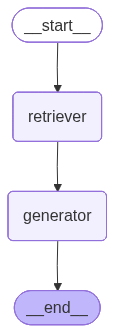

In [ ]:
# Visualize the graph (optional)
rag_pipeline

---

### Helper Function for Easy Querying

Let's create a convenient wrapper to run queries through our pipeline.

In [ ]:
def query_financial_assistant(question: str) -> dict:
    """
    Query the Financial RAG Assistant.

    Args:
        question: User's financial question.

    Returns:
        Dictionary with answer, sources, and retrieved documents.
    """
    print("\n" + "=" * 70)
    print(f"  Processing Query: {question}")
    print("=" * 70)

    # Initialize state
    initial_state = {
        "question": question,
        "retrieved_docs": [],
        "answer": "",
        "sources": [],
    }

    # Run the pipeline
    result = rag_pipeline.invoke(initial_state)
    # escape dollar signs properly in response
    result['answer'] = result['answer'].replace('$', '\\$')

    return result

---

## 🧪 Step 5 — Testing & Evaluation

Now let's test our Financial RAG Assistant with real-world queries!

---
#### Test Query 1: Emergency Fund (Direct Factual Question)

In [ ]:
query = "How much should I have in an emergency fund?"
result = query_financial_assistant(query)


  Processing Query: How much should I have in an emergency fund?




**Reference Answer (Your answer should have similar elements related to this)**

Also it is ok if your answer is longer or more detailed.



> A good rule of thumb is to keep 3 to 6 months of essential living expenses in your emergency fund. Start by calculating your necessary monthly costs such as housing, utilities, food, transportation, insurance, and other critical bills. Then multiply that total by three to six. This gives you a solid cushion if you face job loss, medical expenses, or another unexpected situation.
>
> If saving that much feels overwhelming at first, begin with a smaller goal. Setting aside $500 to $1,000 can handle many short term emergencies and helps you build the habit of saving.
>
> Keep your emergency fund in a high yield savings account that is easy to access. This way your money earns interest while still being available when you need it.
>
> To stay consistent, set up automatic transfers and treat your savings like a regular monthly bill. Over time, this steady approach helps you build a reliable financial safety net and avoid going into debt when surprises come up.

In [ ]:
display(Markdown(result["answer"]))

Based on the provided context, here is how much you should have in an emergency fund:

- Experts generally recommend saving **3 to 6 months’ worth of essential living expenses**. This amount is intended to cover unexpected expenses such as medical emergencies, job loss, or urgent home repairs.
- If starting from scratch, it is acceptable to begin with a smaller amount, such as **\$500 to \$1,000**, which can cover many short-term needs.
- The emergency fund should be kept in a **high-yield savings account** that is easily accessible, to both grow the fund and allow quick access when needed.

This guidance is drawn from the document titled:  
- **"Emergency Funds — Your Financial Safety Net" (doc_06_emergency_funds.txt)**

Additionally, for the best place to keep your emergency fund, consider:  
- Using a **savings account** rather than a checking account, as savings accounts generally offer higher interest rates and are better suited for storing money over time.  
- Preferably, a **high-yield savings account**, often available online, to maximize interest earnings while maintaining easy access.

This is supported by the document:  
- **"Checking vs. Savings Accounts" (doc_23_checking_vs_savings.txt)**

**Summary:**  
- Aim for 3 to 6 months of essential expenses saved.  
- Start with \$500 to \$1,000 if needed.  
- Keep the fund in a high-yield, easily accessible savings account.

If you want more personalized advice, such as calculating the exact dollar amount based on your monthly expenses, you would need to provide your monthly essential living expenses.

---

#### Test Query 2: Comprehensive Financial Planning (Multi-Document Synthesis)

In [ ]:
query = """"You have no emergency fund, some credit card debt, and an average credit score.
What steps should you take to budget, build savings, pay down debt, and improve your credit safely"""

result = query_financial_assistant(query)


  Processing Query: "You have no emergency fund, some credit card debt, and an average credit score.
What steps should you take to budget, build savings, pay down debt, and improve your credit safely


**Reference Answer (Your answer should have similar elements related to this)**

Also it is ok if your answer is longer or more detailed.

> If you have no emergency fund, some credit card debt, and an average credit score, the key is to move in a clear, steady order instead of trying to fix everything at once.
>
> First, create a simple budget so you know exactly where your money is going. You can use a structure like the 50/30/20 rule or zero based budgeting, where every dollar has a job. Track your spending and adjust each month. The goal is to make sure you are living within your means and freeing up money for savings and debt.
>
> Next, build a small starter emergency fund before aggressively paying off debt. Aim for 500 to 1,000 dollars first. Keep this in a high yield savings account and set up automatic transfers, even if the amount is small. This prevents you from adding more credit card debt when unexpected expenses come up.
>
> Then focus on paying down your credit cards. One effective approach is the debt snowball method. List debts from smallest balance to largest. Pay minimums on all cards, and put any extra money toward the smallest one. Once that is paid off, roll that payment into the next card. This builds momentum and keeps you motivated.
>
> At the same time, work on improving your credit safely. Always pay on time, since payment history has the biggest impact on your score. Try to keep your credit utilization below 30 percent by lowering balances. Avoid opening multiple new accounts in a short period. Check your credit reports regularly to catch errors.
>
> By budgeting carefully, building a starter cushion, reducing debt consistently, and managing credit responsibly, you can strengthen your financial position step by step and reduce stress along the way.

In [ ]:
display(Markdown(result["answer"]))

Based on the provided context documents, here is a structured plan to budget, build savings, pay down debt, and improve your credit safely given that you have no emergency fund, some credit card debt, and an average credit score:

1. **Create a Budget to Manage Your Money Wisely**  
   - Use a budgeting method such as the 50/30/20 rule (needs/wants/savings), zero-based budgeting, or an envelope system to allocate your income effectively.  
   - Track your spending consistently using budgeting apps like YNAB, Mint, or EveryDollar.  
   - Review and adjust your budget monthly to stay on track and ensure you are living within your means.  
   *(Source: doc_05_budgeting.txt)*

2. **Start Building an Emergency Fund**  
   - Aim to save at least \$500 to \$1,000 initially to cover short-term unexpected expenses.  
   - Gradually work toward saving 3 to 6 months’ worth of essential living expenses in a high-yield savings account that is easily accessible.  
   - Automate your savings transfers to treat them like recurring bills, which helps build the fund consistently over time.  
   *(Source: doc_06_emergency_funds.txt)*

3. **Pay Down Credit Card Debt Using a Structured Method**  
   - Consider the debt snowball method: focus on paying off the smallest debt balance first while making minimum payments on other debts. Once the smallest is paid off, roll that payment into the next smallest balance to build momentum and motivation.  
   - This method encourages consistency and psychological reinforcement, which is important for staying on track.  
   *(Source: doc_26_debt_snowball.txt)*

4. **Improve Your Credit Score Safely**  
   - Always pay your bills on time to positively impact the largest factor in your credit score (payment history).  
   - Keep your credit utilization below 30% by paying down balances and avoiding accumulating more debt.  
   - Avoid opening multiple new credit accounts in a short period to prevent negative impacts on your score.  
   - Regularly check your credit report from the three major bureaus (Equifax, Experian, TransUnion) once a year for free at AnnualCreditReport.com to catch errors or fraudulent activity and dispute inaccuracies.  
   *(Sources: doc_01_credit_scores.txt, doc_11_credit_reports.txt)*

5. **Use Appropriate Bank Accounts for Savings and Spending**  
   - Use a checking account for everyday transactions and bill payments.  
   - Use a savings account, preferably a high-yield one, to grow your emergency fund and other short-term savings goals.  
   *(Source: doc_23_checking_vs_savings.txt)*

**Summary:**  
- Start with a clear budget to control your spending.  
- Build an emergency fund gradually, automating savings.  
- Use the debt snowball method to pay down credit card debt effectively.  
- Improve your credit score by timely payments, low utilization, and monitoring your credit reports.  
- Separate your spending and savings accounts to optimize money management.

This plan is grounded entirely in the provided documents and offers a safe, consistent approach to improving your financial health.

---

**Cited Documents:**  
- Budgeting — Taking Control of Your Money (doc_05_budgeting.txt)  
- Emergency Funds — Your Financial Safety Net (doc_06_emergency_funds.txt)  
- Debt Snowball Method — A Strategy to Eliminate Debt (doc_26_debt_snowball.txt)  
- Understanding Credit Scores (doc_01_credit_scores.txt)  
- Credit Reports — Your Financial Resume (doc_11_credit_reports.txt)  
- Checking vs. Savings Accounts (doc_23_checking_vs_savings.txt)

---

#### Test Query 3: 401(k) vs Roth IRA (Comparison Question across multiple documents)

In [ ]:
query = "What is the difference between a 401(k) and a Roth IRA?"

result = query_financial_assistant(query)


  Processing Query: What is the difference between a 401(k) and a Roth IRA?


**Reference Answer (Your answer should have similar elements related to this)**

Also it is ok if your answer is longer or more detailed.

> The main difference between a 401(k) and a Roth IRA comes down to how they are taxed, how they are set up, and how withdrawals work in retirement.
>
> A 401(k) is usually offered through your employer. Contributions are typically made with pre tax dollars, which lowers your taxable income today. The money grows tax deferred, but when you withdraw it in retirement, you pay ordinary income tax on those withdrawals. Many employers also offer a match, which can significantly increase your retirement savings.
>
> A Roth IRA is an individual retirement account that you open on your own. Contributions are made with after tax dollars, so you do not get a tax break upfront. However, qualified withdrawals in retirement are completely tax free, as long as you meet age and holding period requirements.
>
> Contribution limits also differ. 401(k) plans generally allow higher annual contributions. Roth IRAs have lower limits and income restrictions that may affect eligibility.
>
> Another key difference is required minimum distributions. Traditional 401(k) plans require distributions starting at age 73 in most cases. Roth IRAs do not have required minimum distributions during your lifetime, giving you more flexibility.
>
> In short, a 401(k) offers pre tax contributions and potential employer matching, while a Roth IRA offers tax free withdrawals and more control in retirement.

In [ ]:
display(Markdown(result["answer"]))

Based on the provided documents, the key differences between a 401(k) and a Roth IRA are as follows:

1. **Tax Treatment of Contributions and Withdrawals:**

   - **401(k):** Contributions are usually made *pre-tax*, which lowers your taxable income today. The funds grow tax-deferred, but withdrawals in retirement are taxed as ordinary income. Early withdrawals before age 59½ may incur taxes and penalties, with some exceptions. (Source: *401(k) Plans — Employer-Sponsored Retirement Benefits*)

   - **Roth IRA:** Contributions are made with *after-tax* income (no immediate tax deduction). Qualified withdrawals—taken after age 59½ and at least five years after the first contribution—are completely *tax-free*. (Source: *Roth IRA — Tax-Free Retirement Savings*)

2. **Contribution Limits and Eligibility:**

   - Both accounts have annual contribution limits set by the IRS, but the Roth IRA has income eligibility thresholds that may restrict who can contribute. (Sources: *Roth IRA — Tax-Free Retirement Savings*, *401(k) Plans — Employer-Sponsored Retirement Benefits*)

3. **Required Minimum Distributions (RMDs):**

   - **401(k):** RMDs are mandatory starting at age 73 unless you are still working. (Source: *401(k) Plans — Employer-Sponsored Retirement Benefits*)

   - **Roth IRA:** There are *no* RMDs during the account holder’s lifetime, providing more flexibility and control over the funds. (Source: *Roth IRA — Tax-Free Retirement Savings*)

4. **Employer Involvement and Matching:**

   - **401(k):** Offered by employers, often with employer matching contributions, which can significantly boost savings. (Source: *401(k) Plans — Employer-Sponsored Retirement Benefits*)

   - **Roth IRA:** An individual retirement account opened and managed by the individual, with no employer involvement or matching. (Source: *Roth IRA — Tax-Free Retirement Savings*)

5. **Investment Control and Options:**

   - The documents do not provide detailed information on investment options or control differences between the two accounts.

**Summary:**

| Feature                  | 401(k)                                      | Roth IRA                                  |
|--------------------------|---------------------------------------------|-------------------------------------------|
| Contribution Type        | Pre-tax contributions                        | After-tax contributions                    |
| Taxation on Withdrawals  | Taxed as ordinary income                      | Tax-free if qualified                       |
| RMDs                    | Required starting at age 73 (unless working) | No RMDs                                     |
| Employer Match          | Often available                               | Not available                              |
| Income Eligibility      | Generally no income limits for contributions | Subject to income eligibility thresholds  |

**References:**

- *401(k) Plans — Employer-Sponsored Retirement Benefits* (doc_04_401k_plans.txt)  
- *Roth IRA — Tax-Free Retirement Savings* (doc_03_roth_ira.txt)

---

#### Test Query 4: Debt-Snowball Method and Personal Advice - Partially answerable (method yes, exact schedule no)

In [ ]:
query = "How does the debt snowball method work, and based on my exact debts and income, when will I be completely debt-free?"
result = query_financial_assistant(query)


  Processing Query: How does the debt snowball method work, and based on my exact debts and income, when will I be completely debt-free?


**Reference Answer (Your answer should have similar elements related to this)**

Also it is ok if your answer is longer or more detailed.

> How the Debt Snowball Method Works
>
> The debt snowball method is a simple repayment strategy that focuses on building momentum.
>
> 1. List all your debts from smallest balance to largest balance.  
2. Make the minimum payment on every debt.  
3. Put any extra money you can toward the smallest debt.  
4. Once the smallest debt is paid off, take the full amount you were paying on it and roll that into the next smallest debt.  
5. Repeat this process until all debts are gone.  
>
> The goal is to create quick wins. Paying off smaller balances first helps you stay motivated and consistent throughout your debt repayment journey.
>
> When Will You Be Completely Debt-Free?
>
> Your exact debt-free timeline depends on your specific financial details. To calculate it accurately, you would need:
>
> - Each debt balance  
> - Interest rates  
> - Minimum payments  
> - Your monthly take-home income  
> - The extra amount you can consistently allocate toward debt  
>
> Without these numbers, it is not possible to estimate your payoff date.
>
> If you share your exact debts, interest rates, and monthly payment capacity, a step-by-step payoff timeline can be calculated for you.



In [ ]:
display(Markdown(result["answer"]))

Based on the provided context, here is how the debt snowball method works and what information is needed to determine when you will be completely debt-free:

### How the Debt Snowball Method Works
- Focus on paying off the smallest debt balance first while making minimum payments on all other debts.
- Once the smallest debt is fully paid, take the amount you were paying on it and apply that payment to the next smallest debt.
- This creates momentum and psychological motivation through quick wins.
- It is especially effective for those who need encouragement to stay consistent, though it may not be the most cost-efficient method compared to alternatives like the debt avalanche method.
- The key is consistency and building motivation to continue paying down debts.

*(Source: "Debt Snowball Method — A Strategy to Eliminate Debt," doc_26_debt_snowball.txt)*

### When Will You Be Completely Debt-Free?
- The context does not provide a formula or timeline calculation for when you will be debt-free based on your exact debts and income.
- To determine your debt-free date using the debt snowball method, you would need:
  - A detailed list of all your debts with their current balances.
  - The minimum monthly payments for each debt.
  - Your total monthly amount available to allocate toward debt repayment.
  - The order of debts from smallest to largest balance.
- With this information, you could calculate how long it will take to pay off each debt sequentially, rolling payments into the next debt.

### Summary
- The debt snowball method prioritizes paying off the smallest debts first to build motivation.
- Exact timing for becoming debt-free depends on your specific debts, minimum payments, and available income for debt repayment.
- Since this detailed personal financial data is not provided in the context, I cannot calculate your debt-free date.

If you can provide your list of debts, balances, minimum payments, and monthly budget for debt repayment, I can help guide you on estimating your timeline using the debt snowball method.

*(Source cited: doc_26_debt_snowball.txt)*

---

#### Test Query 5: Out-of-Scope Query (Hallucination Test)

This is a critical test to ensure our system does not make up stuff but rather gives an informed response only using the context available and also clearly mentions what it cannot answer and what information it might need to be able to give a better answer.

In [ ]:
query = "Exactly how much money will I need to retire at age 60, and what monthly investment amount guarantees I get there?"
result = query_financial_assistant(query)


  Processing Query: Exactly how much money will I need to retire at age 60, and what monthly investment amount guarantees I get there?


**Reference Answer (Your answer should have similar elements related to this)**

Also it is ok if your answer is longer or more detailed.

> How Much Money Will You Need to Retire at Age 60?  
>
> There is no single exact dollar amount that applies to everyone. A common guideline is to plan for **70 to 80 percent of your pre-retirement income each year** in retirement.  
>
> For example, if you earn 80,000 dollars per year, you may want 56,000 to 64,000 dollars per year in retirement income.  
>
> From there, you estimate how many years you expect to live in retirement and factor in:
> - Inflation  
> - Healthcare costs  
> - Social Security benefits  
> - Pensions or other guaranteed income  
>
> A commonly used planning shortcut is the 4 percent rule. Under this approach, you multiply your desired annual retirement income by 25.  
>
> Example:  
> If you need 60,000 dollars per year, you may need about 1.5 million dollars saved (60,000 × 25).  
>
> This is a planning estimate, not a guarantee.
>
> What Monthly Investment Amount Guarantees You Get There?  
>
> No investment amount can guarantee you reach a retirement goal because returns are not guaranteed. Markets fluctuate, inflation changes, and personal circumstances evolve.
>
> However, you can estimate a required monthly investment based on:
> - Your current age  
> - Your target retirement age (60)  
> - Your current savings  
> - Your expected annual return  
> - Your target retirement amount  
>
> The longer you have to invest, the less you need to contribute monthly. The shorter your timeline, the more aggressive your savings rate must be.
>
> For example, if you need 1.5 million dollars by age 60:
> - With 25 years to invest at an average 7 percent return, you might need roughly 1,800 to 2,200 dollars per month depending on current savings.
> - With 15 years, that number rises significantly.
>
> These are estimates, not guarantees.
>
> What You Need to Calculate It Precisely  
>
> To give you an exact projection, I would need:
> - Your current age  
> - Current retirement savings  
> - Annual income  
> - Expected retirement lifestyle  
> - Expected Social Security or pension income  
> - Risk tolerance and expected return assumption  
>
> With those numbers, a detailed retirement projection and monthly contribution target can be calculated.
>
> Retirement planning is about probabilities and disciplined investing, not guarantees. The earlier and more consistently you invest, the more flexibility you will have.


In [ ]:
display(Markdown(result["answer"]))

Based on the provided context documents, here is what can be determined regarding how much money you will need to retire at age 60 and what monthly investment amount guarantees reaching that goal:

1. **How much money you will need to retire at age 60:**

   - According to *Retirement Planning Basics* (doc_02_retirement_planning.txt), a common guideline is to aim for replacing 70% to 80% of your pre-retirement income annually during retirement.
   - The exact amount depends on your current income, expected lifestyle, healthcare costs, inflation, longevity, and other personal factors.
   - The documents do not provide a specific dollar amount or formula to calculate the total retirement savings needed at age 60.

2. **What monthly investment amount guarantees reaching that goal:**

   - *Compound Interest — Letting Your Money Work for You* (doc_10_compound_interest.txt) explains that starting early and investing consistently is key to growing your savings.
   - An example given is investing \$100 monthly from age 25 to 65 at a 7% annual return results in over \$250,000.
   - However, there is no exact formula or guaranteed monthly investment amount provided in the documents to reach a specific retirement savings target by age 60.
   - The documents emphasize that investment returns are subject to market fluctuations and that no guaranteed amount can be stated without knowing your target retirement savings, expected rate of return, and time horizon.

**Summary:**

- To determine exactly how much money you need to retire at 60, you must calculate 70% to 80% of your current annual income and estimate how many years you expect to live in retirement, adjusting for inflation and healthcare costs (*Retirement Planning Basics*).
- To find the monthly investment amount needed to reach that savings goal, you would need to know:
  - Your target retirement savings amount.
  - The expected annual rate of return on your investments.
  - The number of years you have until age 60.
- The documents do not provide a direct calculation or guarantee for the monthly investment amount.

**What additional information is needed:**

- Your current annual income.
- Your target replacement income percentage (within the 70%-80% guideline).
- Expected retirement duration (life expectancy).
- Expected average annual return on investments.
- Current savings and investment starting age.

With this information, a financial advisor or retirement calculator could estimate the total savings needed and the monthly investment required.

---

**References:**

- *Retirement Planning Basics* (doc_02_retirement_planning.txt)
- *Compound Interest — Letting Your Money Work for You* (doc_10_compound_interest.txt)

---

## 🎉 Congratulations!

You've successfully built a production-ready **Financial Intelligence RAG Assistant** using LangGraph!

### What You've Accomplished

✅ **Created a vector database** with financial guidance documents  
✅ **Implemented multiple retrieval strategies** (semantic and hybrid search)  
✅ **Built a LangGraph pipeline** with observable state management  
✅ **Applied strict grounding principles** to prevent hallucination  
✅ **Tested with real-world queries** including out-of-scope scenarios  

### Key Takeaways

1. **RAG is about grounding** — The most important feature is ensuring answers come from documents
2. **Retrieval matters** — Different strategies work better for different query types
3. **State management is crucial** — LangGraph makes complex workflows maintainable
4. **Testing is essential** — Always test refusal behavior and out-of-scope queries
5. **Production-ready means observable** — Each step should be transparent and debuggable

---

**Great work on completing Mini Project 2!** 🚀